# **Diffusion Processes and the Fokker–Planck Equation**

This notebook introduces **diffusion processes** as solutions to stochastic differential equations (SDEs) and studies their probability densities via the **Fokker–Planck (forward Kolmogorov) equation**. We derive the PDE, examine exact solutions for classic examples, and implement a finite-difference solver for numerical validation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully!")


Libraries loaded successfully!


---
## **1. Diffusion Processes: Definition**

A **diffusion process** $(X_t)_{t \geq 0}$ on $\mathbb{R}$ is the strong solution to an SDE of the form:

$$dX_t = \mu(X_t, t) \, dt + \sigma(X_t, t) \, dW_t, \quad X_0 = x_0$$

where:
- $\mu(x,t)$ is the **drift coefficient**
- $\sigma(x,t)$ is the **diffusion coefficient**
- $W_t$ is a standard Brownian motion

### Infinitesimal Generator

The associated **infinitesimal generator** $\mathcal{L}$ acts on smooth functions $f$ as:

$$\mathcal{L}f(x) = \mu(x) \frac{\partial f}{\partial x} + \frac{\sigma^2(x)}{2} \frac{\partial^2 f}{\partial x^2}$$

This operator encodes the local dynamics and is the key to deriving the evolution equations for probability densities.


---
## **2. The Fokker–Planck Equation**

Let $p(x,t)$ denote the probability density of $X_t$. Then $p$ evolves according to the **Fokker–Planck equation** (also called the **forward Kolmogorov equation**):

$$\frac{\partial p}{\partial t} = -\frac{\partial}{\partial x}\bigl[\mu(x) \, p(x,t)\bigr] + \frac{\partial^2}{\partial x^2}\left[\frac{\sigma^2(x)}{2} \, p(x,t)\right]$$

### Equivalent Flux Form

Define the **probability current** (or flux):

$$J(x,t) = \mu(x) \, p(x,t) - \frac{\partial}{\partial x}\left[\frac{\sigma^2(x)}{2} \, p(x,t)\right]$$

Then the FPE becomes the **continuity equation**:

$$\frac{\partial p}{\partial t} + \frac{\partial J}{\partial x} = 0$$

### Stationary Distribution

A density $p_\infty(x)$ is **stationary** if $\partial_t p = 0$, which requires:

$$\frac{\partial J}{\partial x} = 0 \quad \Longrightarrow \quad J = \text{constant}$$

For natural boundary conditions ($p, J \to 0$ as $|x| \to \infty$), the stationary density satisfies:

$$\mu(x) \, p_\infty(x) = \frac{d}{dx}\left[\frac{\sigma^2(x)}{2} \, p_\infty(x)\right]$$


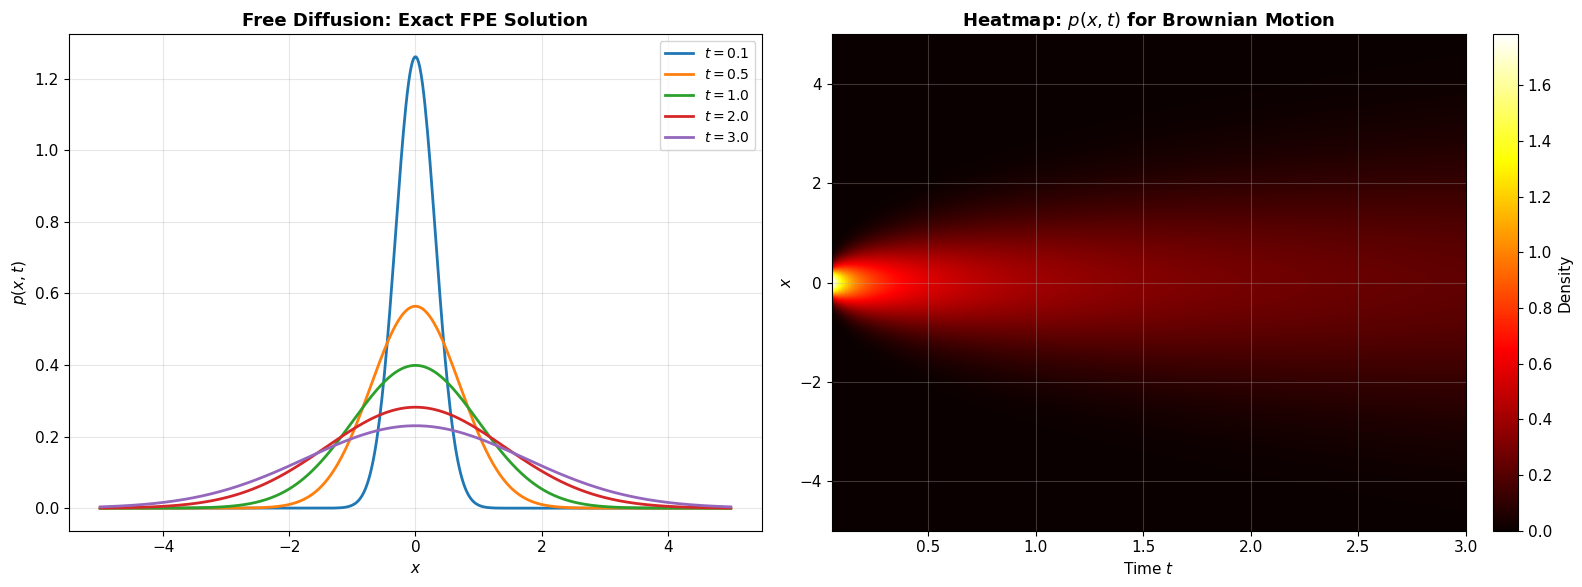

In [2]:
# ============================================================
# 3. Free Diffusion (Brownian Motion): Exact Solution
# ============================================================

np.random.seed(1)

sigma = 1.0
x = np.linspace(-5, 5, 500)
t_vals = [0.1, 0.5, 1.0, 2.0, 3.0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: density slices ---
ax = axes[0]
for t in t_vals:
    p = (1.0 / np.sqrt(2 * np.pi * sigma**2 * t)) * np.exp(-x**2 / (2 * sigma**2 * t))
    ax.plot(x, p, linewidth=2, label=rf'$t = {t}$')
ax.set_title('Free Diffusion: Exact FPE Solution', fontsize=13, fontweight='bold')
ax.set_xlabel('$x$', fontsize=11)
ax.set_ylabel('$p(x,t)$', fontsize=11)
ax.legend(fontsize=10)

# --- Right: heatmap ---
ax = axes[1]
t_grid = np.linspace(0.05, 3.0, 200)
T_mesh, X_mesh = np.meshgrid(t_grid, x)
P = np.zeros_like(T_mesh)
mask = T_mesh > 0
P[mask] = (1.0 / np.sqrt(2 * np.pi * sigma**2 * T_mesh[mask])) * np.exp(
    -X_mesh[mask]**2 / (2 * sigma**2 * T_mesh[mask])
)

im = ax.imshow(P, aspect='auto', origin='lower',
               extent=[t_grid[0], t_grid[-1], x[0], x[-1]],
               cmap='hot', vmin=0)
ax.set_title('Heatmap: $p(x,t)$ for Brownian Motion', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$x$', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Density')

plt.tight_layout()
plt.show()


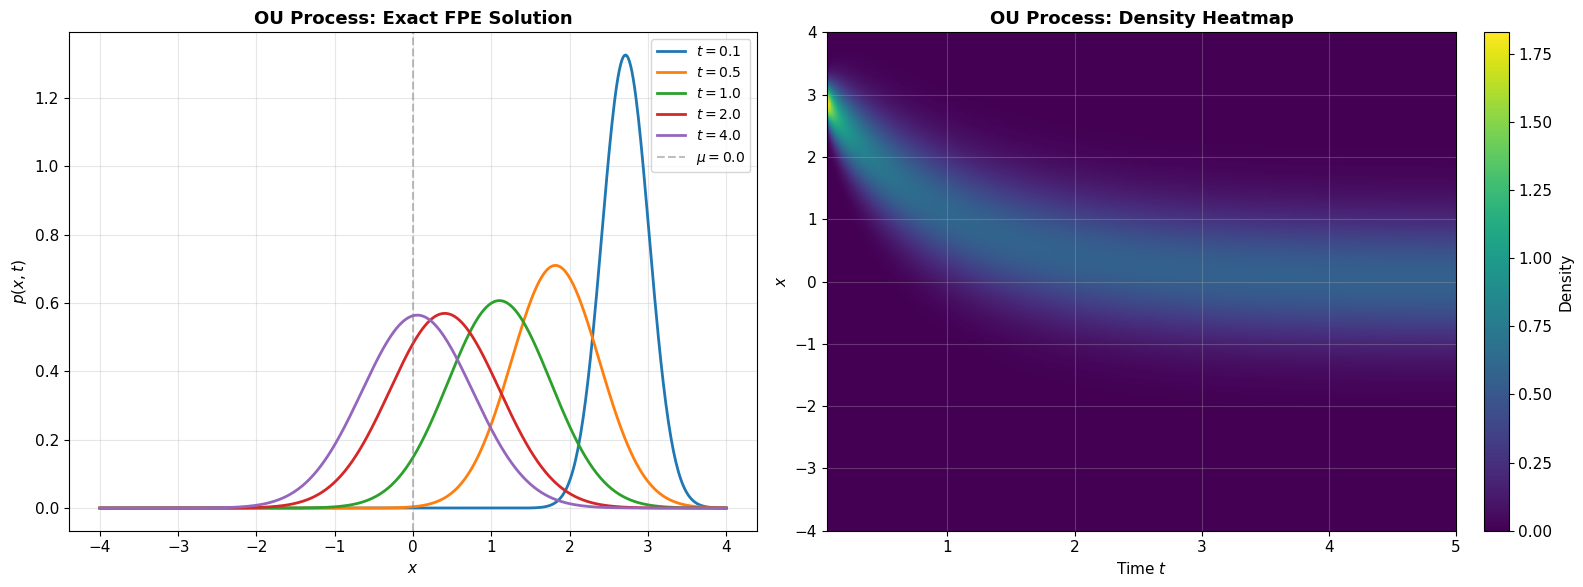

In [3]:
# ============================================================
# 4. Ornstein-Uhlenbeck: Exact FPE Solution
# ============================================================

np.random.seed(2)

mu, theta, sigma = 0.0, 1.0, 1.0
x0 = 3.0
x = np.linspace(-4, 4, 500)
t_vals = [0.1, 0.5, 1.0, 2.0, 4.0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: density slices ---
ax = axes[0]
for t in t_vals:
    mean_t = mu + (x0 - mu) * np.exp(-theta * t)
    var_t = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))
    p = (1.0 / np.sqrt(2 * np.pi * var_t)) * np.exp(-(x - mean_t)**2 / (2 * var_t))
    ax.plot(x, p, linewidth=2, label=rf'$t = {t}$')
ax.axvline(x=mu, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label=rf'$\mu = {mu}$')
ax.set_title('OU Process: Exact FPE Solution', fontsize=13, fontweight='bold')
ax.set_xlabel('$x$', fontsize=11)
ax.set_ylabel('$p(x,t)$', fontsize=11)
ax.legend(fontsize=10)

# --- Right: heatmap ---
ax = axes[1]
t_grid = np.linspace(0.05, 5.0, 300)
x_grid = np.linspace(-4, 4, 300)
T_mesh, X_mesh = np.meshgrid(t_grid, x_grid)
mean_t = mu + (x0 - mu) * np.exp(-theta * T_mesh)
var_t = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * T_mesh))
P = (1.0 / np.sqrt(2 * np.pi * var_t)) * np.exp(-(X_mesh - mean_t)**2 / (2 * var_t))

im = ax.imshow(P, aspect='auto', origin='lower',
               extent=[t_grid[0], t_grid[-1], x_grid[0], x_grid[-1]],
               cmap='viridis', vmin=0)
ax.set_title('OU Process: Density Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$x$', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Density')

plt.tight_layout()
plt.show()


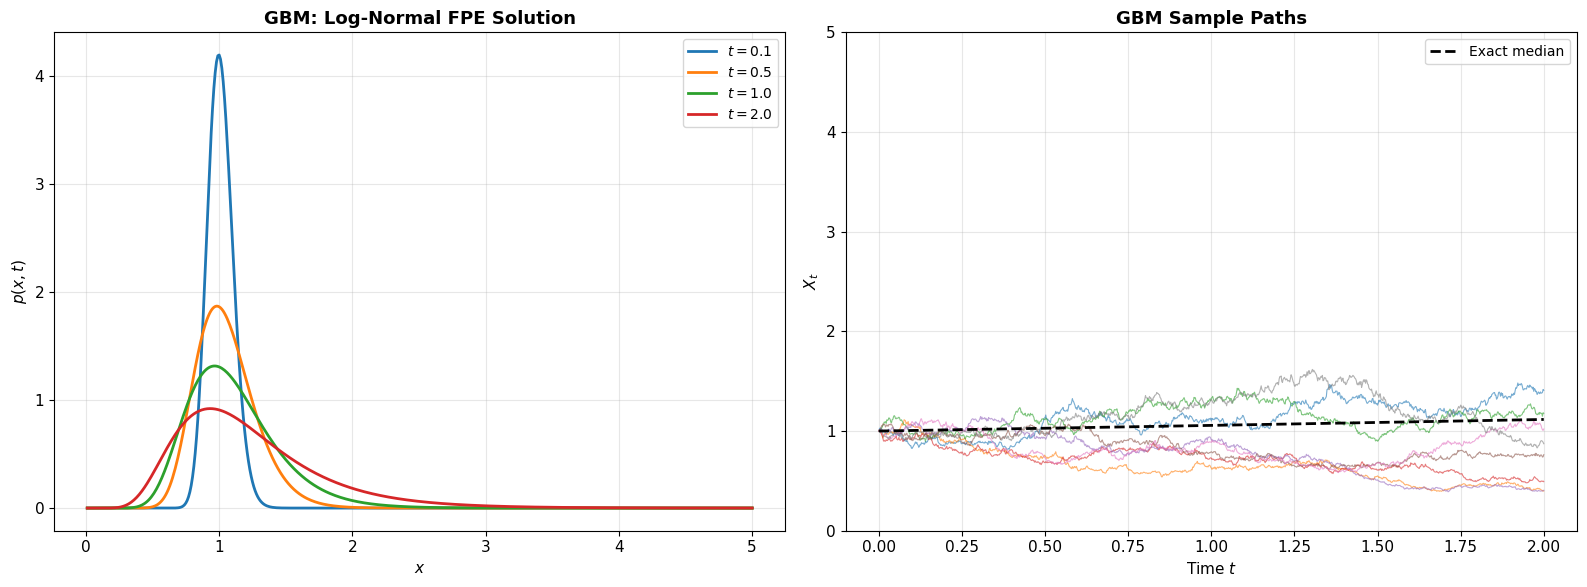

In [4]:
# ============================================================
# 5. Geometric Brownian Motion: Log-Normal Density
# ============================================================

np.random.seed(3)

mu_gbm = 0.1
sigma_gbm = 0.3
x0_gbm = 1.0
x = np.linspace(0.01, 5.0, 500)
t_vals = [0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: density slices ---
ax = axes[0]
for t in t_vals:
    mean_log = np.log(x0_gbm) + (mu_gbm - 0.5 * sigma_gbm**2) * t
    var_log = sigma_gbm**2 * t
    p = (1.0 / (x * np.sqrt(2 * np.pi * var_log))) * np.exp(
        -(np.log(x) - mean_log)**2 / (2 * var_log)
    )
    ax.plot(x, p, linewidth=2, label=rf'$t = {t}$')
ax.set_title('GBM: Log-Normal FPE Solution', fontsize=13, fontweight='bold')
ax.set_xlabel('$x$', fontsize=11)
ax.set_ylabel('$p(x,t)$', fontsize=11)
ax.legend(fontsize=10)

# --- Right: sample paths + median ---
ax = axes[1]
T = 2.0
N = 1000
dt = T / N
t_path = np.linspace(0, T, N + 1)
median_exact = x0_gbm * np.exp((mu_gbm - 0.5 * sigma_gbm**2) * t_path)

for i in range(8):
    dW = np.random.normal(0, np.sqrt(dt), size=N)
    X = np.zeros(N + 1)
    X[0] = x0_gbm
    for j in range(N):
        X[j+1] = X[j] * np.exp((mu_gbm - 0.5 * sigma_gbm**2) * dt + sigma_gbm * dW[j])
    ax.plot(t_path, X, alpha=0.6, linewidth=0.8)

ax.plot(t_path, median_exact, 'k--', linewidth=2, label='Exact median')
ax.set_title('GBM Sample Paths', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 5)

plt.tight_layout()
plt.show()


---
## **6. Numerical Solution of the FPE**

For processes without closed-form density solutions, we solve the FPE numerically. We use a **finite-difference method** on the OU process to verify against the exact Gaussian solution.

### Discretization

On a spatial grid $x_i = x_{\min} + i \Delta x$ and time steps $t_n = n \Delta t$:

$$\frac{p_i^{n+1} - p_i^n}{\Delta t} = -\frac{v_{i+1} p_{i+1}^n - v_{i-1} p_{i-1}^n}{2 \Delta x} + D \frac{p_{i+1}^n - 2p_i^n + p_{i-1}^n}{\Delta x^2}$$

where $v(x) = \theta(\mu - x)$ and $D = \sigma^2/2$.

### Stability

The explicit scheme requires:

$$\Delta t \lesssim \min\left( \frac{\Delta x^2}{2D}, \frac{\Delta x}{|v|_{\max}} \right)$$

Boundary conditions are approximated by Neumann (zero-flux) mirroring at the edges.


Stability limits: diffusive = 0.00090, advective = 0.00500, used dt = 0.00050


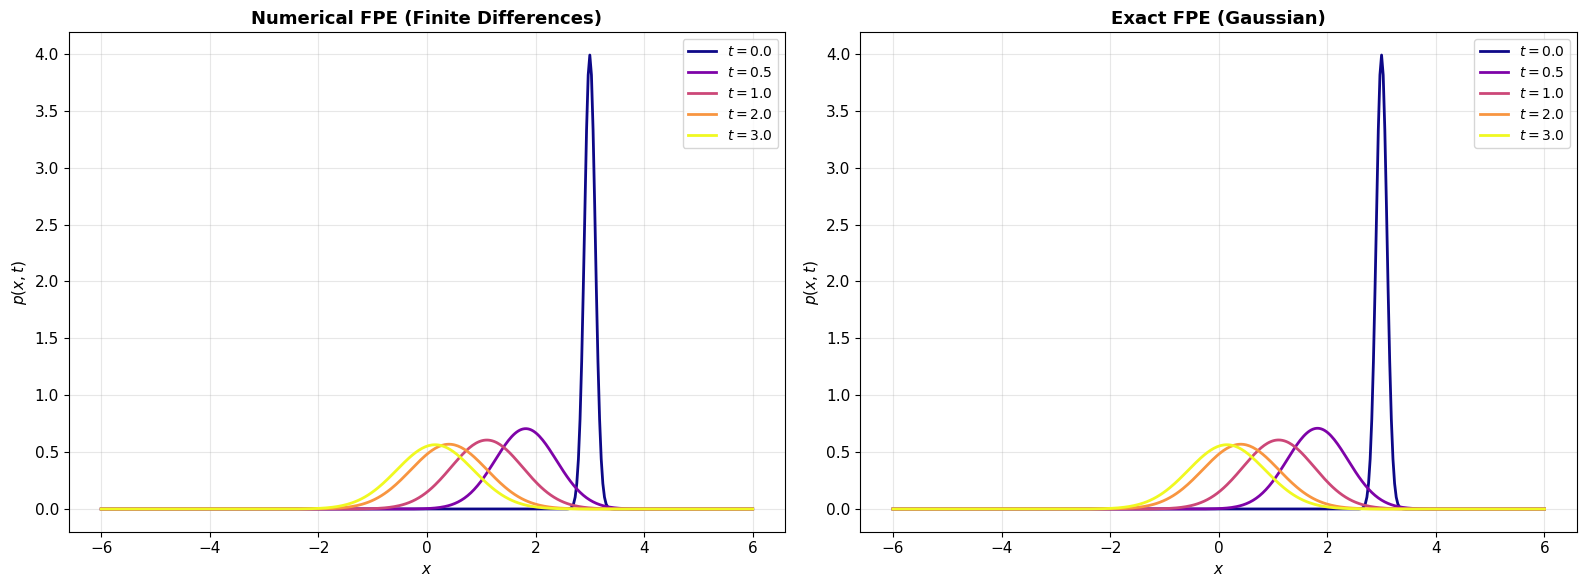

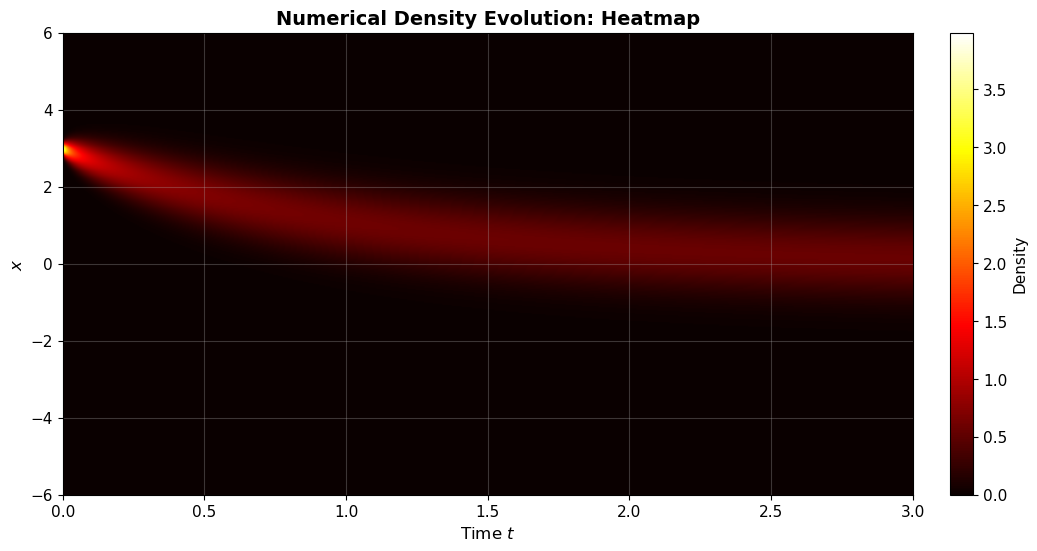

In [5]:
# ============================================================
# Numerical FPE Solver: Finite Differences for OU
# ============================================================

np.random.seed(10)

# Parameters
mu, theta, sigma = 0.0, 1.0, 1.0
x0 = 3.0
D = sigma**2 / 2.0

# Grid
x_min, x_max = -6.0, 6.0
Nx = 400
dx = (x_max - x_min) / Nx
x_grid = np.linspace(x_min, x_max, Nx + 1)

T_final = 3.0
Nt = 6000
dt = T_final / Nt

# Stability check
dt_diff = dx**2 / (2 * D)
v_max = theta * max(abs(x_min - mu), abs(x_max - mu))
dt_adv = dx / v_max if v_max > 1e-10 else np.inf
print(f"Stability limits: diffusive = {dt_diff:.5f}, advective = {dt_adv:.5f}, used dt = {dt:.5f}")

# Initial condition: narrow Gaussian at x0
p = (1.0 / np.sqrt(2 * np.pi * 0.01)) * np.exp(-(x_grid - x0)**2 / (2 * 0.01))
p = p / (np.sum(p) * dx)

# Time stepping
snap_times = [0.0, 0.5, 1.0, 2.0, 3.0]
snap_indices = [int(np.round(t / dt)) for t in snap_times]
snapshots = []
P_history = np.zeros((Nt + 1, Nx + 1))
P_history[0, :] = p

for n in range(Nt):
    if n in snap_indices:
        snapshots.append(p.copy())
    
    v = theta * (mu - x_grid)
    dpdt = np.zeros_like(p)
    # Central difference for advection + diffusion
    dpdt[1:-1] = -(v[2:] * p[2:] - v[:-2] * p[:-2]) / (2 * dx) + D * (p[2:] - 2 * p[1:-1] + p[:-2]) / dx**2
    # Neumann-like boundaries
    dpdt[0] = dpdt[1]
    dpdt[-1] = dpdt[-2]
    
    p_new = p + dt * dpdt
    p_new = np.maximum(p_new, 0.0)
    p = p_new / (np.sum(p_new) * dx)
    P_history[n + 1, :] = p

if Nt in snap_indices:
    snapshots.append(p.copy())

# --- Line comparison: numerical vs exact ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.plasma(np.linspace(0, 1, len(snap_times)))

# Numerical
ax = axes[0]
for idx, (t_snap, p_num) in enumerate(zip(snap_times, snapshots)):
    ax.plot(x_grid, p_num, color=colors[idx], linewidth=2, label=rf'$t = {t_snap}$')
ax.set_title('Numerical FPE (Finite Differences)', fontsize=13, fontweight='bold')
ax.set_xlabel('$x$', fontsize=11)
ax.set_ylabel('$p(x,t)$', fontsize=11)
ax.legend(fontsize=10)

# Exact
ax = axes[1]
for idx, t_snap in enumerate(snap_times):
    if t_snap > 0:
        mean_t = mu + (x0 - mu) * np.exp(-theta * t_snap)
        var_t = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t_snap))
        p_exact = (1.0 / np.sqrt(2 * np.pi * var_t)) * np.exp(-(x_grid - mean_t)**2 / (2 * var_t))
    else:
        p_exact = (1.0 / np.sqrt(2 * np.pi * 0.01)) * np.exp(-(x_grid - x0)**2 / (2 * 0.01))
    ax.plot(x_grid, p_exact, color=colors[idx], linewidth=2, label=rf'$t = {t_snap}$')
ax.set_title('Exact FPE (Gaussian)', fontsize=13, fontweight='bold')
ax.set_xlabel('$x$', fontsize=11)
ax.set_ylabel('$p(x,t)$', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# --- Heatmap of numerical evolution ---
fig, ax = plt.subplots(figsize=(12, 6))
t_grid = np.linspace(0, T_final, Nt + 1)
im = ax.imshow(P_history.T, aspect='auto', origin='lower',
               extent=[t_grid[0], t_grid[-1], x_grid[0], x_grid[-1]],
               cmap='hot', vmin=0)
ax.set_title('Numerical Density Evolution: Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('$x$', fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Density')
plt.show()


---
## **7. Application: Wright–Fisher Diffusion**

In population genetics, the **Wright–Fisher diffusion** models the frequency $X_t \in [0,1]$ of an allele in a large population:

$$dX_t = \sqrt{X_t(1-X_t)} \, dW_t$$

The drift is zero (neutral evolution), and the diffusion coefficient $D(x) = \frac{1}{2}x(1-x)$ vanishes at the boundaries $x=0$ and $x=1$. These are **absorbing** boundaries representing allele fixation or loss.

### Fokker–Planck Equation

$$\frac{\partial p}{\partial t} = \frac{1}{2} \frac{\partial^2}{\partial x^2}\bigl[x(1-x) \, p(x,t)\bigr]$$

This is a singular diffusion with no simple closed-form solution for the transition density. We visualize the density evolution via Monte Carlo simulation of many paths.


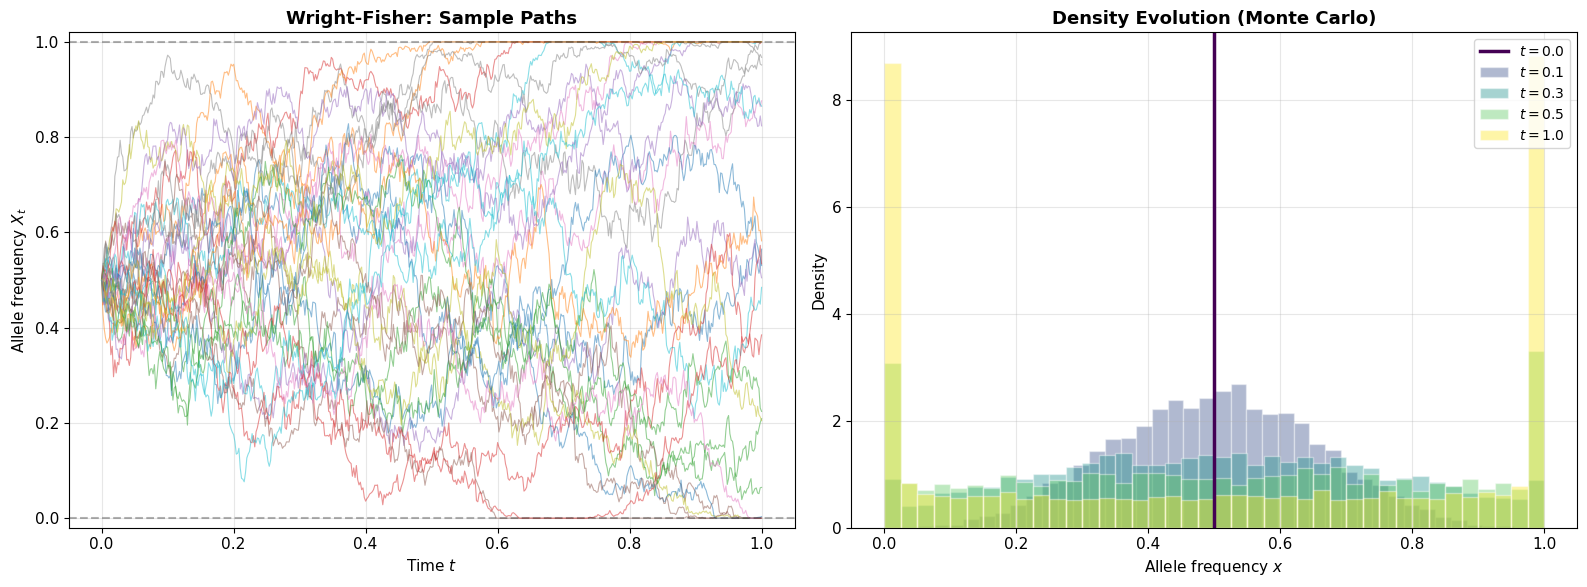

Absorption at 0: 0.201
Absorption at 1: 0.205
Still polymorphic: 0.594


In [6]:
# ============================================================
# Wright-Fisher Diffusion: Monte Carlo Density Evolution
# ============================================================

np.random.seed(20)

def simulate_wright_fisher(X0, T, N, n_paths=5000):
    dt = T / N
    all_paths = np.zeros((n_paths, N + 1))
    all_paths[:, 0] = X0
    for i in range(N):
        X = all_paths[:, i]
        dW = np.random.normal(0, np.sqrt(dt), size=n_paths)
        diffusion = np.sqrt(np.maximum(X * (1.0 - X), 0.0))
        X_new = X + diffusion * dW
        all_paths[:, i + 1] = np.clip(X_new, 1e-8, 1.0 - 1e-8)
    t = np.linspace(0, T, N + 1)
    return t, all_paths


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: sample paths ---
ax = axes[0]
t, paths = simulate_wright_fisher(0.5, 1.0, 500, n_paths=200)
for i in range(30):
    ax.plot(t, paths[i], alpha=0.5, linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.axhline(y=1, color='black', linestyle='--', alpha=0.3)
ax.set_title('Wright-Fisher: Sample Paths', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('Allele frequency $X_t$', fontsize=11)
ax.set_ylim(-0.02, 1.02)

# --- Right: density evolution ---
ax = axes[1]
t, paths = simulate_wright_fisher(0.5, 1.0, 500, n_paths=8000)
times = [0.0, 0.1, 0.3, 0.5, 1.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(times)))
dt_step = t[1] - t[0]

for t_val, color in zip(times, colors):
    idx = int(np.round(t_val / dt_step))
    data = paths[:, idx]
    if t_val == 0:
        ax.axvline(x=data[0], color=color, linewidth=2.5, label=rf'$t = {t_val}$')
    else:
        ax.hist(data, bins=40, density=True, alpha=0.4, color=color,
                edgecolor='white', label=rf'$t = {t_val}$')

ax.set_title('Density Evolution (Monte Carlo)', fontsize=13, fontweight='bold')
ax.set_xlabel('Allele frequency $x$', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Fixation probability by time
fix_0 = np.mean(paths[:, -1] < 0.01)
fix_1 = np.mean(paths[:, -1] > 0.99)
print(f"Absorption at 0: {fix_0:.3f}")
print(f"Absorption at 1: {fix_1:.3f}")
print(f"Still polymorphic: {1 - fix_0 - fix_1:.3f}")


---
## **8. Summary**

| Process | SDE | Fokker–Planck | Exact Density? |
|---------|-----|---------------|----------------|
| **Brownian motion** | $dX_t = \sigma \, dW_t$ | $\partial_t p = \frac{\sigma^2}{2} \partial_{xx} p$ | Gaussian |
| **Ornstein–Uhlenbeck** | $dX_t = \theta(\mu-X_t)dt + \sigma dW_t$ | $\partial_t p = -\partial_x[\theta(\mu-x)p] + \frac{\sigma^2}{2}\partial_{xx}p$ | Gaussian |
| **Geometric BM** | $dX_t = \mu X_t dt + \sigma X_t dW_t$ | $\partial_t p = -\partial_x[\mu x p] + \frac{\sigma^2}{2}\partial_{xx}[x^2 p]$ | Log-normal |
| **Wright–Fisher** | $dX_t = \sqrt{X_t(1-X_t)} dW_t$ | $\partial_t p = \frac{1}{2}\partial_{xx}[x(1-x)p]$ | No (singular) |

### Key Formulas

**Fokker–Planck:**
$$\partial_t p = -\partial_x(\mu p) + \partial_{xx}\left(\frac{\sigma^2}{2} p\right)$$

**Stationary density** (when $\sigma > 0$):
$$p_\infty(x) \propto \frac{1}{\sigma^2(x)} \exp\left( \int^x \frac{2\mu(y)}{\sigma^2(y)} dy \right)$$

### References

1. **Risken, H.** (1989). *The Fokker–Planck Equation: Methods of Solution and Applications* (2nd ed.). Springer.
2. **Gardiner, C.W.** (2009). *Stochastic Methods: A Handbook for the Natural and Social Sciences* (4th ed.). Springer.
3. **Oksendal, B.** (2003). *Stochastic Differential Equations* (6th ed.). Springer.
4. **Ewens, W.J.** (2004). *Mathematical Population Genetics* (2nd ed.). Springer.
